# Learning the Tax-Loss-Harvest Decision at Scale

### From a two-year proof of concept to a twenty-year, multi-regime stress test

**Gabriel Kung** · DirectIndexing v0.3 · continuation of the PSTAT 231 final project
University of California, Santa Barbara

Code: [github.com/ieatyoursushi/DirectIndexing_ML](https://github.com/ieatyoursushi/DirectIndexing_ML)
— a .NET 8 pipeline (data download → portfolio simulation → ML.NET training) with this
report layer rendered in Python. This document extends the original two-year study to roughly
two decades of real S&P 500 history — **1,846,015 lot-day observations** spanning the 2008
financial crisis, the 2020 COVID crash, and the 2022 selloff — and reorients the analysis
from "can we recover the harvest rule" toward "what would a *live* tax-alpha system need, and
what does a twenty-year stress test reveal about its readiness."

## Table of Contents

1. [Introduction](#Introduction)
2. [Data Source and the Two Regimes](#Data-Source-and-the-Two-Regimes)
3. [Loading the Data](#Loading-the-Data)
4. [Codebook](#Codebook)
5. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
   - [The outcomes, one variable at a time](#The-outcomes,-one-variable-at-a-time)
   - [Cost-basis aging: why the harvest signal thins over twenty years](#Cost-basis-aging:-why-the-harvest-signal-thins-over-twenty-years)
   - [The portfolio through two decades of regimes](#The-portfolio-through-two-decades-of-regimes)
   - [Which gate actually binds?](#Which-gate-actually-binds?)
   - [Missing data](#Missing-data)
   - [Outcome versus predictors](#Outcome-versus-predictors)
   - [Correlation structure](#Correlation-structure)
6. [Data Splitting and Cross-Validation](#Data-Splitting-and-Cross-Validation)
7. [The Recipe: Feature Handling](#The-Recipe:-Feature-Handling)
8. [Model Fitting and Tuning](#Model-Fitting-and-Tuning)
9. [Model Selection and Test-Set Performance](#Model-Selection-and-Test-Set-Performance)
10. [The Headline: Decision Geometry Is Regime-Dependent](#The-Headline:-Decision-Geometry-Is-Regime-Dependent)
11. [Unsupervised Structure](#Unsupervised-Structure)
12. [Toward a Live Tax-Alpha System](#Toward-a-Live-Tax-Alpha-System)
13. [Conclusion](#Conclusion)
14. [References and Reproducibility](#References-and-Reproducibility)

## Introduction

**Direct indexing** holds an index's constituent stocks directly rather than through a single
fund, so that individual positions can be sold at a loss to **harvest** a tax deduction while
the portfolio as a whole continues to track the benchmark. The unit of bookkeeping is the
**lot** — a parcel of shares of one stock bought on one day at one price (its **cost basis**) —
and every harvesting decision is made lot by lot, subject to three real constraints: the IRS
**wash-sale rule** (a 30-day repurchase lockout), a **tracking-error** budget (how far the
holdings may drift from the index), and the availability of realized **gains to offset**.

In the language of the **Capital Asset Pricing Model**, write a portfolio's excess return as
$R_p - r_f = \alpha_p + \beta_p (R_B - r_f) + \varepsilon_p$, with
$\beta_p = \operatorname{Cov}(R_p, R_B)/\operatorname{Var}(R_B)$. An index fund is the
degenerate case $\beta = 1, \alpha = 0$. A direct-indexing portfolio is better thought of as
an **estimator of the index**, $\hat\beta_{DI}$: built from the constituents, it holds
$\hat\beta_{DI} \approx 1$ while the harvesting engine adds an after-tax
$\alpha_{\text{tax}} > 0$ sourced from the tax code rather than from security selection. The
estimator degrades exactly when lots are harvested — each wash-sale absence nudges
$\hat\beta_{DI}$ off 1 and adds idiosyncratic variance — and the two effects sum to the
**tracking error** $\sigma_{TE}^2 = (\hat\beta_{DI}-1)^2\operatorname{Var}(R_B) +
\operatorname{Var}(\varepsilon_{DI})$. Direct indexing in one line: *hold
$\hat\beta_{DI}\approx 1$, harvest $\alpha$ from the tax code.*

The "correct" harvest decision is encoded as a deterministic **oracle** — harvest lot $k$ on
day $t$ exactly when all four gates are open:

$$
f^*(x) = \mathbb{1}[L \le -0.02]\cdot\mathbb{1}[\sigma_{TE}\le 0.05]\cdot
\mathbb{1}[G^{\mathrm{YTD}}>0]\cdot\mathbb{1}[\mathcal W \ge 30],
$$

where $L$ is the lot's unrealized return, $G^{\mathrm{YTD}}$ the net realized gain year-to-date,
and $\mathcal W$ the wash-sale clock. (The full portfolio mathematics are in
`DataMemo/PortfolioMath.md` and `DataMemo/SimulationMath.md`.) One caveat to carry through the
whole report: the third gate, $G^{\mathrm{YTD}}>0$, is now a **tracked design defect** (issue
#23) — the twenty-year run supplies the evidence against it, and a note in
[Which gate actually binds?](#Which-gate-actually-binds?) explains why it is slated for
removal/redesign in v0.25.

**Why scale to twenty years.** The PSTAT 231 submission learned this decision from a single
**two-year window (2024–2026)** — a smooth bull market with only micro-drawdowns. That run
answered the academic question (yes, the boundary is learnable; gradient-boosted trees win)
but left a glaring external-validity question: *does any of it survive a real bear market?* The
**data window is now a parameter of the study**: the download layer accepts an arbitrary
`--from`/`--to` date range (issues #19/#20), bounded in practice at ~20 years by the price
API's ≈5,000-bars-per-ticker response cap, and the simulation adapts to whatever range the
cache holds. This report re-runs the entire pipeline on roughly **two decades of history
through three major crises** and asks three questions:

1. **Robustness.** Does the champion model's forward-harvest-propensity skill survive 2008,
   2020, and 2022, or was it an artifact of a calm market?
2. **Regime dependence of the geometry.** The two-year run found that the oracle's
   *learnability by linear models* depended on which gates bind. Does twenty years of varied
   regimes confirm or overturn that?
3. **Live-system readiness.** What does the long horizon expose about the simulation's design
   choices — the constant gains seed, the fixed cost basis — that a production tax-alpha engine
   would have to fix? This document is preparation for the live-simulation layer (v0.4–v0.5),
   not a deployment of it.

The two predictive targets are unchanged: the hard oracle label `Y_Oracle`, and the
forward-looking **soft label** `Y_Soft_BT > 0` ("will the oracle fire on this lot within the
next 30 trading days?"), which depends on unobserved future prices and is therefore the
genuine prediction problem.

## Data Source and the Two Regimes

Two external sources feed the pipeline; everything else is derived. **Daily prices** are
end-of-day OHLCV bars for the S&P 500 constituents from the Financial Modeling Prep (FMP) API
(`/stable/historical-price-eod/full`), now pulled over a configurable date range via
`dotnet run download --from YYYY-MM-DD --to YYYY-MM-DD` (the original run hardcoded two years).
With no explicit dates the downloader falls back to a rolling `years`-long window; either way it
extends the fetch backward by ≈200 trading days so the moving-average features are defined on
the portfolio's first day, warns when a custom range is too short for that warmup, and
re-aggregates an existing cache incrementally instead of re-downloading it. The practical
ceiling is the API itself — ≈5,000 daily bars per ticker, which is what pins *this* run's
window to **2006-07 through 2026-06**. **Index membership** comes from State Street's SPDR
S&P 500 ETF (SPY) daily holdings file.

> Financial Modeling Prep. (2026). *Historical Price EOD API* [Data set].
> https://financialmodelingprep.com/
>
> State Street Global Advisors. (2026). *SPDR S&P 500 ETF Trust (SPY) Daily Holdings*
> [Data set]. https://www.ssga.com/

**A survivorship caveat, stated up front.** Membership and weights come from *today's* SPY
holdings, but a 20-year price window only exists for the **409 constituents** with two
decades of continuous history — down from the 503 in the two-year run. Names that were added,
dropped, merged, or delisted over the period are absent, so the universe is **survivorship-
biased toward long-lived large caps**. This inflates index returns and understates idiosyncratic
risk relative to a true point-in-time membership; a production system would need a point-in-time
constituent feed (flagged as future work). It does not bias the *harvest-decision* learning
problem, which is conditional on each lot's own state, but it does mean the absolute
tax-alpha and tracking-error magnitudes here are optimistic.

**Provenance.** Real prices drive a \$10M equal-dollar simulated portfolio opened after a
200-trading-day moving-average warmup; the backtesting engine marks every lot to market each
day, evaluates the oracle, executes harvests (re-buying after the 30-day wash window), and
writes one row per open lot per day to `data/lots.csv`. The result is **1,846,015 rows × 21
columns** across Timesteps 200–4999 (≈19 active years). Every column is defined in the
[Codebook](#Codebook) and the standalone `codebook.md`.

| | PSTAT 231 run | This run |
|---|---|---|
| Window | 2024–2026 (≈2 yr) | 2006-07 – 2026-06 (≈20 active yr) |
| Market character | smooth bull, micro-drawdowns | 2008 GFC, 2020 COVID, 2022 bear |
| Constituents | 503 | 409 |
| Rows | ~170,751 | 1,846,015 |
| `Y_Oracle` positive rate | 1.6% | 0.20% |
| `Y_Soft_BT > 0` rate | 19.9% | 2.47% |

## Loading the Data

The notebook locates the repository root the same way the .NET orchestrator does (walking up
to `DirectIndexing.sln`), so it runs identically under `dotnet run report` and interactively.

In [75]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_here = Path.cwd()
_ml_dir = _here if (_here / "scripts").exists() else _here.parent
if str(_ml_dir) not in sys.path:
    sys.path.insert(0, str(_ml_dir))

from scripts import report_helpers as rh

rh.set_style()
ROOT = rh.repo_root()
ART  = ROOT / "data" / "artifacts-mlnet"

lots = pd.read_csv(ROOT / "data" / "lots.csv")
SIM_YEAR = (lots["Timestep"] - 200) / 252.0          # approx. years since portfolio open
print(f"{len(lots):,} rows x {lots.shape[1]} columns | "
      f"Timesteps {lots['Timestep'].min()}-{lots['Timestep'].max()} "
      f"(~{SIM_YEAR.max():.1f} active years) | {lots['Symbol'].nunique()} tickers")
lots.head()

FileNotFoundError: [Errno 2] No such file or directory

## Codebook

One row is a **lot snapshot** — the state of one tax lot on one simulated trading day: fifteen
numeric features (lot-, portfolio-, asset-level, and derived), one categorical, three metadata
columns dropped before modeling, and the labels. The table below renders the same schema that
generates the standalone codebook, so the two cannot drift.

In [78]:
from scripts.codebook_schema import COLUMNS
pd.DataFrame(COLUMNS)[["name", "dtype", "units", "role", "encoding"]] \
    .style.hide(axis="index").set_properties(**{"text-align": "left"})

name,dtype,units,role,encoding
L,float,unitless (fractional return),feature (lot-level),"Continuous in (−1, ∞). Negative = loss position."
H,int,trading days,feature (lot-level),Non-negative integer.
S,int (binary),—,feature (lot-level),"0 = short-term (< 365 days), 1 = long-term (≥ 365 days)."
B,float,US dollars per share,feature (lot-level),Positive continuous.
W,float,unitless (portfolio fraction),feature (lot-level),"Continuous in (0, 1)."
K,int,count,feature (lot-level),Positive integer.
G_YTD,float,US dollars,feature (portfolio-level),Signed continuous. Positive = net realized gains.
Sigma_TE,float,annualized volatility (fraction),feature (portfolio-level),Positive continuous; 0.05 = 5% annualized TE.
WashClock,int,calendar days,feature (portfolio-level),Non-negative integer. Sentinel 999 = ticker never harvested.
R_t,float,unitless (daily return),feature (asset-level),Signed continuous.


## Exploratory Data Analysis

The twenty-year EDA is organized around one surprise: **the harvest event got an order of
magnitude rarer.** The sections below establish that fact, diagnose its cause (cost-basis
aging, not market calm), locate the bear-market regimes in the data, and identify which oracle
gate actually constrains the decision now.

### The outcomes, one variable at a time

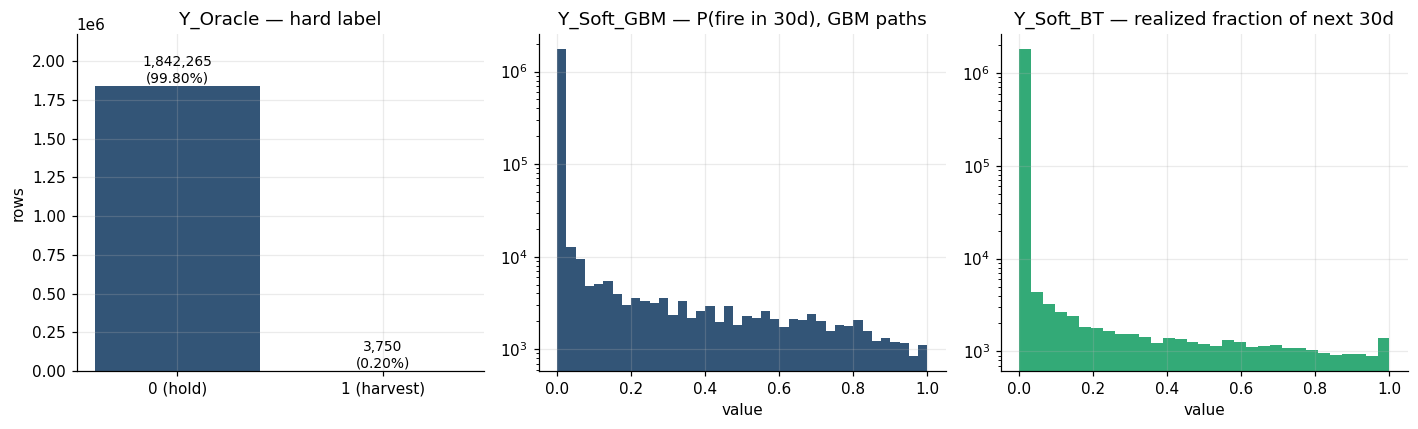

Y_Oracle = 1:               0.20%
Y_Soft_BT > 0 (of labeled): 2.47%


In [96]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

counts = lots["Y_Oracle"].value_counts().sort_index()
bars = axes[0].bar(["0 (hold)", "1 (harvest)"], counts.values, color=["#357", "#a33"])
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, v, f"{v:,}\n({v/len(lots):.2%})",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_ylim(0, counts.max() * 1.18)
axes[0].set_title("Y_Oracle — hard label"); axes[0].set_ylabel("rows")

axes[1].hist(lots["Y_Soft_GBM"], bins=40, color="#357"); axes[1].set_yscale("log")
axes[1].set_title("Y_Soft_GBM — P(fire in 30d), GBM paths"); axes[1].set_xlabel("value")

axes[2].hist(lots["Y_Soft_BT"].dropna(), bins=31, color="#3a7"); axes[2].set_yscale("log")
axes[2].set_title("Y_Soft_BT — realized fraction of next 30d"); axes[2].set_xlabel("value")
fig.tight_layout(); plt.show()

print(f"Y_Oracle = 1:               {lots['Y_Oracle'].mean():.2%}")
print(f"Y_Soft_BT > 0 (of labeled): {(lots['Y_Soft_BT'].dropna() > 0).mean():.2%}")

The hard label fires on only **0.20% of lot-days** — an order of magnitude *rarer*
than the 1.6% of the two-year run, and the soft target drops from 19.9% to **2.47%**.
This is the opposite of what a naïve intuition predicts: twenty years *including three crashes*
should offer **more** harvest opportunities than a calm two-year bull, not fewer. The
resolution is not about the market — it is about the **simulation's cost-basis dynamics**, which
the next section isolates. The methodological consequence is severe: at a 0.20% base
rate, accuracy is meaningless (predicting "never harvest" scores >99.7%), so model selection
uses **PR-AUC** and training uses balanced class weights and stratified splits — the same
discipline as before, but now load-bearing.

### Cost-basis aging: why the harvest signal thins over twenty years

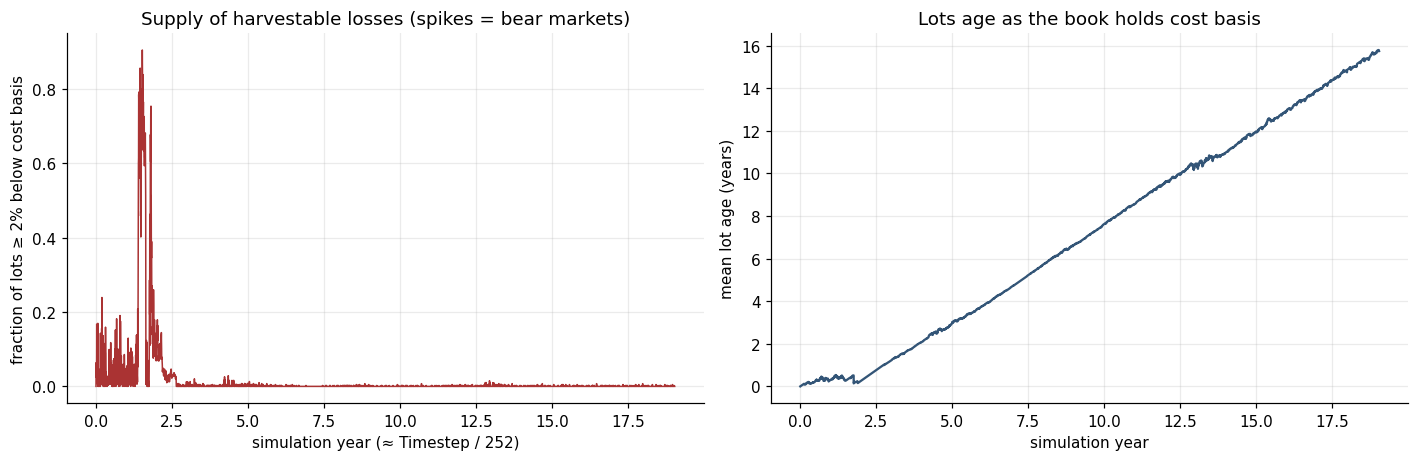

In [79]:
lots["_atloss"] = (lots["L"] <= -0.02).astype(float)
byT = lots.groupby("Timestep").agg(
    frac_loss=("_atloss", "mean"),
    mean_age =("H", "mean"),
    harvests =("Y_Oracle", "sum"),
    gytd     =("G_YTD", "first"),
)
yr = (byT.index - 200) / 252.0

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].plot(yr, byT["frac_loss"].values, color="#a33", lw=1)
axes[0].set_xlabel("simulation year (≈ Timestep / 252)")
axes[0].set_ylabel("fraction of lots ≥ 2% below cost basis")
axes[0].set_title("Supply of harvestable losses (spikes = bear markets)")

axes[1].plot(yr, byT["mean_age"].values / 252.0, color="#357", lw=1.5)
axes[1].set_xlabel("simulation year")
axes[1].set_ylabel("mean lot age (years)")
axes[1].set_title("Lots age as the book holds cost basis")
fig.tight_layout(); plt.show()

The left panel is the mechanism, and it is starker than "spikes at every bear market." There is
**one eruption** — the 2008–09 financial crisis, where at the March-2009 bottom roughly **90% of
the book sits ≥ 2% underwater** — and then the signal never truly returns. The 2020 COVID crash
(a 34% index drawdown) and the 2022 selloff barely register: their daily peaks put only ~1–2%
and well under 1% of lots underwater, respectively. Why? The right panel: lots are opened once
at the warmup day and **hold their cost basis indefinitely** (only a harvest-and-reopen resets
it), so mean lot age climbs steadily and the un-harvested lots accumulate years of appreciation.
A position carrying a 2007 basis is so deep in the money by 2020 that a one-third market crash
cannot push it 2% below cost. The portfolio **ages out of harvestability** — harvests become
rare, bursty, and (after the first decade) nearly extinct even in genuine crashes.

This is the single most important finding of the scale-up, and it is a *simulation-design*
finding, not a market finding: a real direct-indexing account receives ongoing contributions
and rebalances, continuously minting fresh lots at current prices that *can* dip. The
open-once / hold-forever design has no such mechanism, so over long horizons it understates
harvest opportunity. The fix — modeling contributions and rebalancing — is exactly what the
[live-system section](#Toward-a-Live-Tax-Alpha-System) returns to.

### The portfolio through two decades of regimes

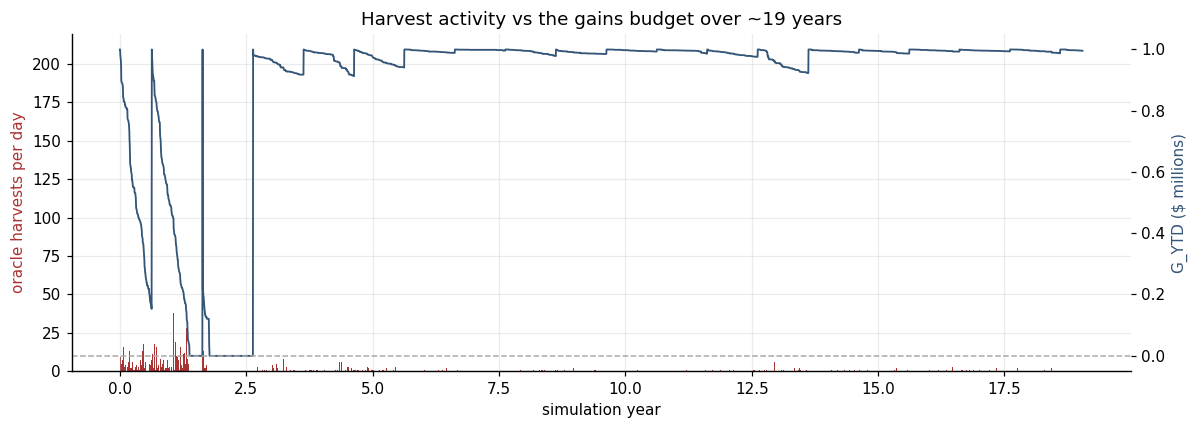

In [97]:
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(yr, byT["harvests"].values, color="#a33", width=(yr.max()/len(yr)),
        label="harvests/day")
ax1.set_xlabel("simulation year"); ax1.set_ylabel("oracle harvests per day", color="#a33")
ax2 = ax1.twinx()
ax2.plot(yr, byT["gytd"].values / 1e6, color="#357", lw=1.2, label="G_YTD ($M)")
ax2.axhline(0, color="#aaa", lw=1, ls="--"); ax2.grid(False)
ax2.set_ylabel("G_YTD ($ millions)", color="#357")
ax1.set_title("Harvest activity vs the gains budget over ~19 years")
fig.tight_layout(); plt.show()

Harvesting is **regime-clustered**: the red bars are nearly silent in the long expansions and
fire in dense bursts during the drawdowns — precisely when a tax-alpha engine earns its keep.
Of the ≈3,750 oracle harvests in the whole run, some 2,900 happen in the first two simulation
years (the GFC); no later year manages even 200.

The blue line is the gains budget `G_YTD`, re-seeded each January to \$1M (10% of the initial
book) and drawn down by realized losses — and it exposes a **self-strangling feedback loop**.
During 2008–09 the harvest bursts realize losses fast enough to burn the \$1M seed to zero
mid-year; the moment `G_YTD` hits the floor, gate 3 slams shut and **freezes all harvesting
until the January re-seed** — in the richest loss environment of the entire window, the engine
spends the majority of the crisis year forbidden to harvest by its own accounting rule. Outside
those two GFC years the same gate never comes close to closing (the seed dwarfs realized
losses). Both failure modes — shut exactly when losses are most abundant, vacuously open the
other ~17 years — belong to the same defect, taken up in the note below.

### Which gate actually binds?

The oracle is a four-way AND. If three gates are almost always open, the decision boundary is
effectively governed by the fourth — and *which* one binds is what makes the problem linear or
non-linear. The chart below shows the marginal pass rate of each gate over all 1,846,015 rows.

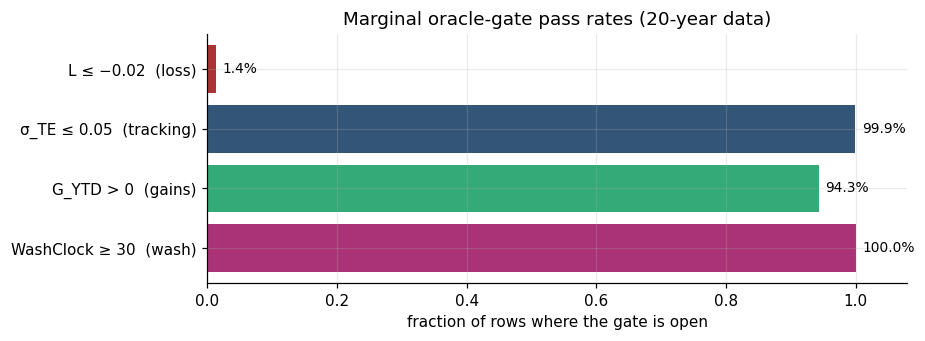

In [81]:
gates = {
    "L ≤ −0.02  (loss)":      (lots["L"] <= -0.02).mean(),
    "σ_TE ≤ 0.05  (tracking)": (lots["Sigma_TE"] <= 0.05).mean(),
    "G_YTD > 0  (gains)":      (lots["G_YTD"] > 0).mean(),
    "WashClock ≥ 30  (wash)":  (lots["WashClock"] >= 30).mean(),
}
fig, ax = plt.subplots(figsize=(8.5, 3.2))
names = list(gates); vals = [gates[k] for k in names]
bars = ax.barh(names, vals, color=["#a33", "#357", "#3a7", "#a37"])
for b, v in zip(bars, vals):
    ax.text(v + 0.01, b.get_y() + b.get_height()/2, f"{v:.1%}", va="center", fontsize=9)
ax.set_xlim(0, 1.08); ax.set_xlabel("fraction of rows where the gate is open")
ax.set_title("Marginal oracle-gate pass rates (20-year data)")
ax.invert_yaxis(); fig.tight_layout(); plt.show()

Marginal rates hide *when* a gate matters, and with twenty years of regimes the time dimension
is the story — so the next chart re-computes each gate's pass rate **per simulation year**.

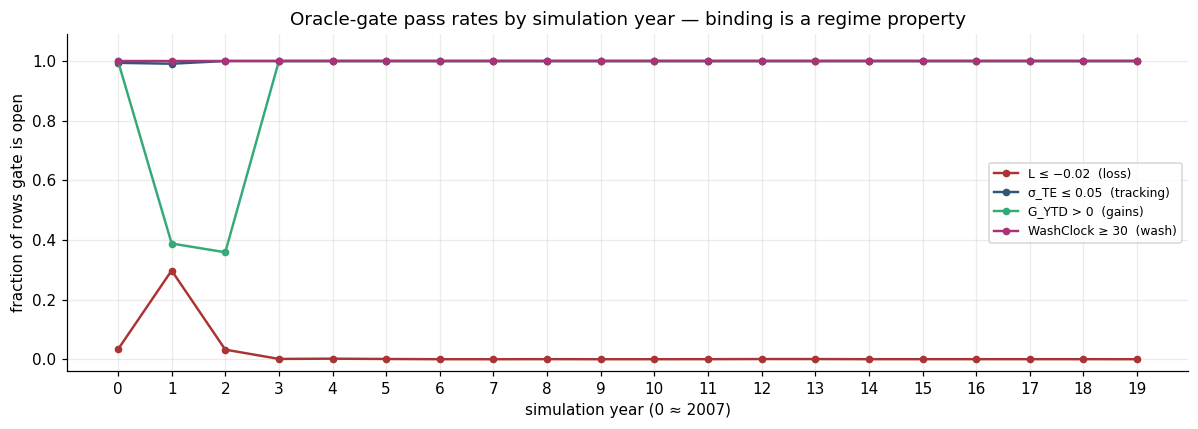

In [82]:
simyr = ((lots["Timestep"] - 200) // 252).astype(int)
gate_by_year = pd.DataFrame({
    "L ≤ −0.02  (loss)":       lots["L"] <= -0.02,
    "σ_TE ≤ 0.05  (tracking)": lots["Sigma_TE"] <= 0.05,
    "G_YTD > 0  (gains)":      lots["G_YTD"] > 0,
    "WashClock ≥ 30  (wash)":  lots["WashClock"] >= 30,
}).groupby(simyr).mean()

fig, ax = plt.subplots(figsize=(11, 4))
for name, color in zip(gate_by_year.columns, ["#a33", "#357", "#3a7", "#a37"]):
    ax.plot(gate_by_year.index, gate_by_year[name], marker="o", ms=4, lw=1.6,
            label=name, color=color)
ax.set_xlabel("simulation year (0 ≈ 2007)"); ax.set_ylabel("fraction of rows gate is open")
ax.set_ylim(-0.04, 1.09); ax.set_xticks(gate_by_year.index)
ax.set_title("Oracle-gate pass rates by simulation year — binding is a regime property")
ax.legend(fontsize=8, loc="center right"); fig.tight_layout(); plt.show()

The two charts together say the gate structure is **regime-dependent, and degenerately so**.
The gains gate `G_YTD > 0` is open on **94.3% of rows** overall — near-vestigial — but
the per-year view shows *all* of its closure concentrated in simulation years 1–2 (the GFC and
its aftermath), where it is shut on roughly 60% of lot-days. Every other year it is open on
essentially 100% of rows. The binding constraint everywhere else is the **loss gate**: the
cost-basis aging above means very few lots are ever 2% underwater, so it is the loss condition,
not the availability of gains, that starves the harvest signal. This matters twice over. As a
*modeling* fact, it reshapes which models can recover the boundary (see
[the headline](#The-Headline:-Decision-Geometry-Is-Regime-Dependent)). As an *economic* fact,
the gains gate's behavior is exactly backwards: it blocks harvesting only during the one regime
where losses are abundant, and rubber-stamps it the other seventeen years.

> **Note — the `G_YTD` gate is now a tracked defect (issue #23, targeted for v0.25).** The
> twenty-year evidence above crystallized into a redesign of the oracle itself, on two counts.
> **(1) The seed is a simulation artifact:** the constant \$1M January re-seed neither scales
> with the growing book nor reflects any client's actual tax situation, so the gate's
> open/closed state is an accounting fiction. **(2) The gate is conceptually misaligned with
> beta-tracking direct indexing.** In production stock-level TLH engines (e.g., Wealthfront's),
> the engine's mandate is to hold $\hat\beta_{DI} \approx 1$ and capture losses when they
> exceed the trade-off threshold; *whether* those losses offset gains this year is the client
> tax return's concern, since US tax law lets unused losses offset \$3k of ordinary income and
> carry forward indefinitely. A hard "must have realized gains this year" trigger is therefore
> **stricter than the tax code** and refuses real tax alpha — most visibly in this run's
> 2008–09 self-strangulation. The redesign (`DataMemo/GYTD_Redesign_Plan.md`,
> `DataMemo/data_memo_theory_part2.md` §C.2.5) removes `G_YTD` as a hard gate and replaces it
> with either a dynamic seed, a continuous tax ledger (carryforward + ordinary-offset budget),
> or gate-plus-reinforcement objectives; all models will be **retrained on the corrected
> oracle**. Every result in this report is on the 4-gate oracle as built.

### Missing data

In [83]:
na = lots.isna().sum()
display(na[na > 0].to_frame("missing cells").assign(
    pct=lambda d: (100 * d["missing cells"] / len(lots)).round(3)))

,missing cells,pct
R_t,2,0.000
SigmaRange,2,0.000
DeltaMA50,99,0.005
DeltaMA200,577,0.031
Y_Soft_BT,12141,0.658


Missingness remains **structural, not accidental**, and at 1.85M rows it is now a vanishing
fraction. `Y_Soft_BT` is undefined for the final 30 simulation days (its forward window runs
off the data) — a known, `Timestep`-determined gap, so those rows are *excluded* from
soft-label training rather than imputed (imputing a label would manufacture ground truth).
`DeltaMA50`/`DeltaMA200` carry a handful of NaNs on tickers with short early histories, handled
by per-fold median imputation. `Sector` remains the degenerate column from the SPY scrape
(≈99% the placeholder `"-"` → "Unknown"); it is cleaned and one-hot encoded for schema honesty
but carries essentially no information — an unchanged data-quality gap.

### Outcome versus predictors

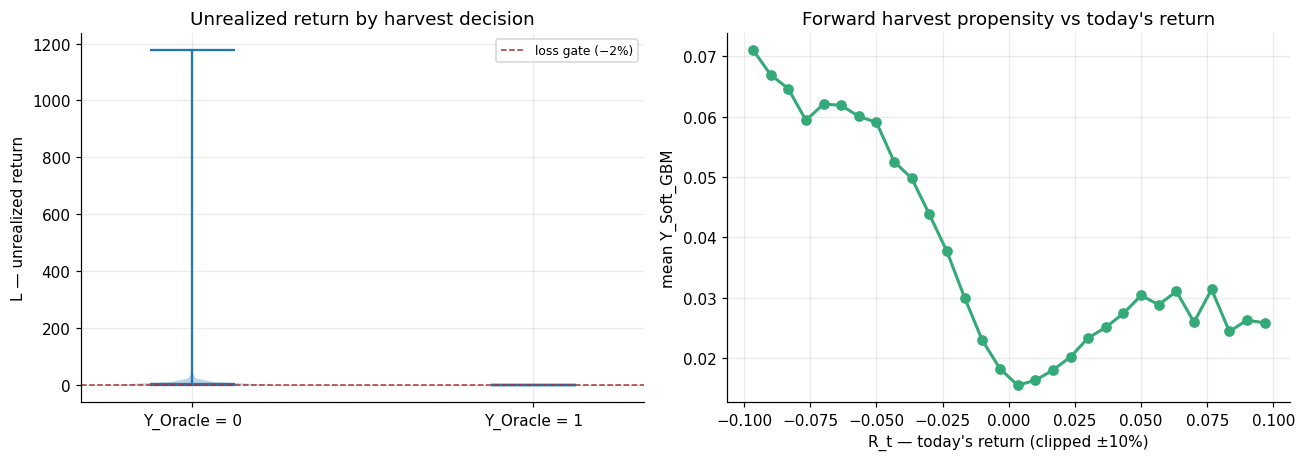

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
data_l = [lots.loc[lots["Y_Oracle"] == 0, "L"], lots.loc[lots["Y_Oracle"] == 1, "L"]]
axes[0].violinplot(data_l, showmedians=True)
axes[0].axhline(-0.02, color="#a33", ls="--", lw=1, label="loss gate (−2%)")
axes[0].set_xticks([1, 2]); axes[0].set_xticklabels(["Y_Oracle = 0", "Y_Oracle = 1"])
axes[0].set_ylabel("L — unrealized return")
axes[0].set_title("Unrealized return by harvest decision"); axes[0].legend(fontsize=8)

rbins = pd.cut(lots["R_t"].clip(-0.10, 0.10), bins=30)
rmean = lots.groupby(rbins, observed=True)["Y_Soft_GBM"].mean()
axes[1].plot([iv.mid for iv in rmean.index], rmean.values, marker="o", color="#3a7", lw=2)
axes[1].set_xlabel("R_t — today's return (clipped ±10%)")
axes[1].set_ylabel("mean Y_Soft_GBM")
axes[1].set_title("Forward harvest propensity vs today's return")
fig.tight_layout(); plt.show()

The violin confirms the loss gate as a hard separator — the harvested class sits entirely below
−2%, with a long tail of un-harvested deep-loss lots where another gate (wash-sale, tracking
error) blocked the trade. The right panel shows the forward soft label rising sharply as today's
return turns negative: a stock falling today is far likelier to cross the loss gate within 30
days. The relationship is monotone but soft — a probability shift, not a determination — which
is exactly the structure a gradient-boosted classifier exploits and a hard threshold cannot.

### Correlation structure

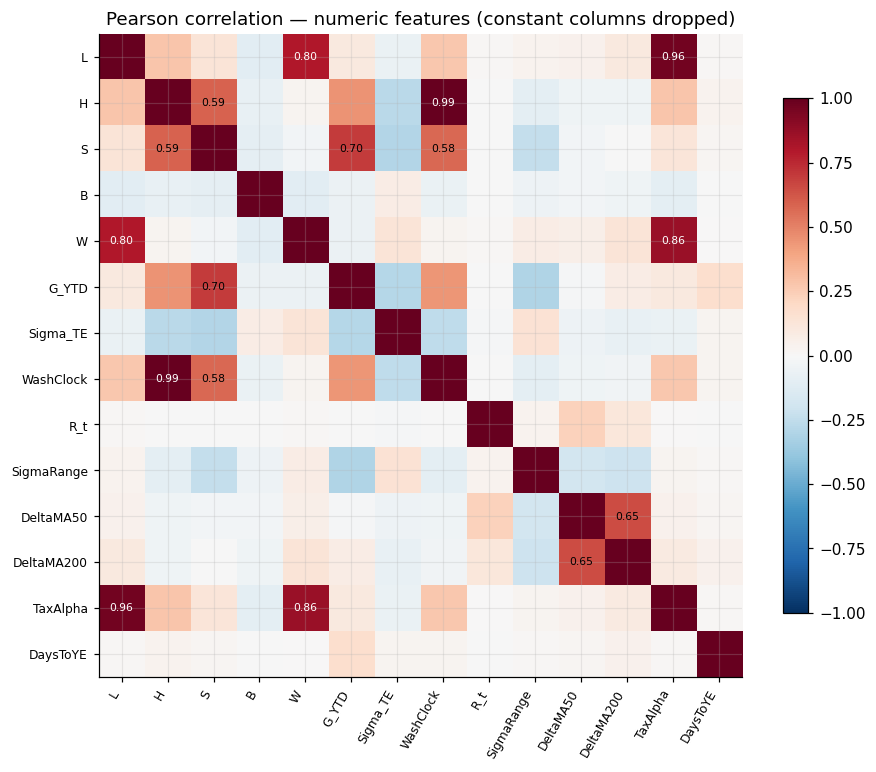

In [85]:
feat = [f for f in rh.NUMERIC_FEATURES if lots[f].nunique() > 1]
corr = lots[feat].corr()
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feat))); ax.set_xticklabels(feat, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(feat))); ax.set_yticklabels(feat, fontsize=8)
for i in range(len(feat)):
    for j in range(len(feat)):
        v = corr.iloc[i, j]
        if abs(v) > 0.45 and i != j:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.7 else "black")
fig.colorbar(im, shrink=0.8)
ax.set_title("Pearson correlation — numeric features (constant columns dropped)")
fig.tight_layout(); plt.show()

The correlation structure is stable across the scale-up: mostly modest off-diagonals, with the
expected blocks — `H`/`S` (long-term flag is a step function of holding age), the moving-average
deviations co-moving with `L`, and the portfolio-level features (`G_YTD`, `Sigma_TE`, `DaysToYE`)
correlated through the shared calendar. Nothing approaches the collinearity that would force
dropping a feature; the regularized linear models absorb this comfortably. As before, `K` (lots
per ticker) and the encoded `Sector` are effectively constant and contribute a zero eigenvalue
we meet again in [PCA](#Unsupervised-Structure).

## Data Splitting and Cross-Validation

*(Written for a general audience.)* Before any model sees the data, **20% of rows are locked
away as a test set** and never touched during development; all learning and tuning happens on
the remaining 80%. Because the positive class is now extraordinarily rare (≈0.20% for
the hard label), the split is **stratified** — each class is divided 80/20 *separately*
(`StratifiedSplit.cs`, seed 42) so both sides inherit the population's class proportion exactly.

Tuning uses **stratified 5-fold cross-validation** on the training set: for each hyperparameter
configuration, the model trains on four folds and is scored on the held-out fifth, rotating five
times, and the five scores are averaged. The score is **PR-AUC** (area under the precision–recall
curve), the right metric under extreme imbalance — ROC-AUC can look excellent while the few true
positives drown in false alarms, exactly what PR-AUC penalizes. Every preprocessing statistic
(imputation medians, class weights, normalization, one-hot vocabulary) is fit on the *training
portion of each fold only* — enforced structurally in the C# pipeline, where the fitting
functions only accept a training fold (`DataMemo/MLNetLeakageAudit.md`).

In [86]:
gbt_soft = rh.load_artifact(ART, "gbt_soft_bt_metrics.json")
gbt_orc  = rh.load_artifact(ART, "gbt_oracle_metrics.json")
pd.DataFrame({
    "target": ["Y_Oracle (hard)", "Y_Soft_BT > 0 (soft)"],
    "usable rows": [gbt_orc["rowsTrain"] + gbt_orc["rowsTest"],
                    gbt_soft["rowsTrain"] + gbt_soft["rowsTest"]],
    "train (80%)": [gbt_orc["rowsTrain"], gbt_soft["rowsTrain"]],
    "test (20%)":  [gbt_orc["rowsTest"],  gbt_soft["rowsTest"]],
}).set_index("target")

,usable rows,train (80%),test (20%)
target,,,
Y_Oracle (hard),1846015,1476812,369203
Y_Soft_BT > 0 (soft),1833874,1467099,366775


## The Recipe: Feature Handling

All models share one preprocessing recipe (an ML.NET `EstimatorChain`, the analogue of a
tidymodels recipe), fit on training data only: **median imputation** of the moving-average NaNs;
**one-hot encoding** of the cleaned `Sector`; **mean-variance normalization** of all fifteen
numeric features (load-bearing for the regularized linear models, where penalties are
scale-sensitive; harmless for trees); **balanced class weights** (≈500:1 at this base rate, so
the rare positives are not ignored); and **concatenation** into one feature vector, with `Symbol`
and `Timestep` held out as metadata. The outcome is then modeled as a binary classification of
`Y_Oracle` or `Y_Soft_BT > 0`, plus one deliberately mis-specified linear *regression* on the
continuous `Y_Soft_BT` retained as a cautionary comparison.

## Model Fitting and Tuning

Five model types were fit and tuned by grid search, each configuration scored by mean PR-AUC
across the stratified 5-fold CV above. **Note for this version:** the random forest now tunes
its **feature-sampling fraction** (the ML.NET analogue of `mtry`/`m`) over {0.3, 0.5, 0.7} — the
single most important RF hyperparameter and the decorrelation knob — in addition to tree count
and leaves, closing a tuning gap from the original submission.

| Model | What it does | Grid searched |
|---|---|---|
| **Logistic (L2)** | linear logit boundary | $C \in \{0.01, 0.1, 1, 10\}$ |
| **Elastic net** | linear with L1+L2 penalties | $\lambda_{L1} \times \lambda_{L2}$, 3×3 |
| **Random forest** | bagged decorrelated trees | trees ∈ {100,200} × leaves ∈ {20,31} × **featureFraction ∈ {0.3,0.5,0.7}** |
| **Gradient boosted trees** | sequential residual-fitting trees | trees ∈ {100,200} × learning rate ∈ {0.05,0.1} × leaves ∈ {20,31} |
| **Linear regression (ridge)** | least-squares on the continuous soft label — a poor-fit demonstration | $\lambda_{L2}$, 3 values |

In [87]:
lb_soft = rh.load_artifact(ART, "soft_bt_cv_leaderboard.json")
lb_orc  = rh.load_artifact(ART, "oracle_cv_leaderboard.json")
print("Cross-validation leaderboard — target = Y_Soft_BT > 0")
display(rh.leaderboard_df(lb_soft).style.format(
    {"mean CV PR-AUC": "{:.4f}", "fold std": "{:.4f}"}).hide(axis="index"))
print("Cross-validation leaderboard — target = Y_Oracle")
display(rh.leaderboard_df(lb_orc).style.format(
    {"mean CV PR-AUC": "{:.4f}", "fold std": "{:.4f}"}).hide(axis="index"))

Cross-validation leaderboard — target = Y_Soft_BT > 0


model,type,mean CV PR-AUC,fold std,configs tried,champion
Gradient Boosted Trees,classifier,0.8499,0.0036,8,★
Random Forest,classifier,0.6474,0.0079,12,★
Logistic Regression (L2),classifier,0.3734,0.0070,4,
Linear Regression,regression_demonstration,0.2850,0.0074,3,
Elastic Net,classifier,0.2752,0.0082,9,


Cross-validation leaderboard — target = Y_Oracle


model,type,mean CV PR-AUC,fold std,configs tried,champion
Gradient Boosted Trees,classifier,0.9765,0.0037,8,★
Random Forest,classifier,0.9518,0.0035,4,★
Logistic Regression (L2),classifier,0.1230,0.0022,4,
Linear Regression,regression_demonstration,0.0758,0.0072,3,
Elastic Net,classifier,0.0741,0.0066,9,


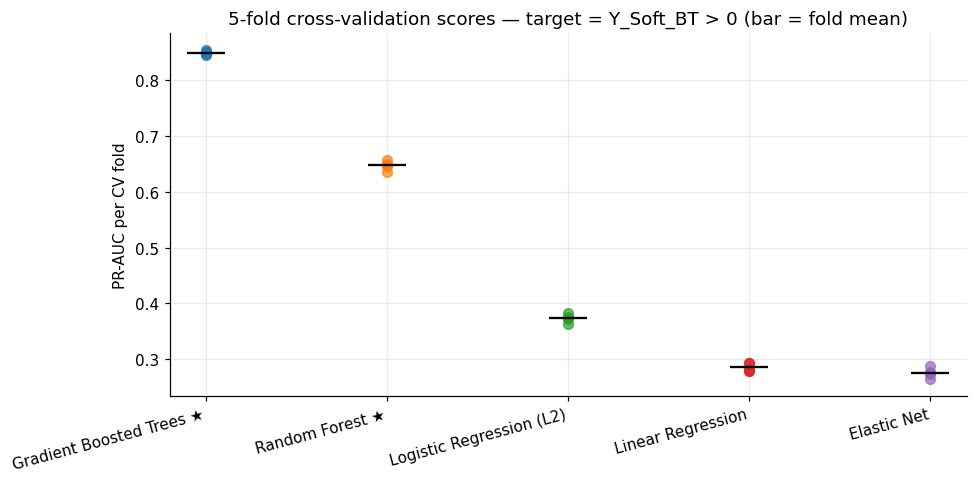

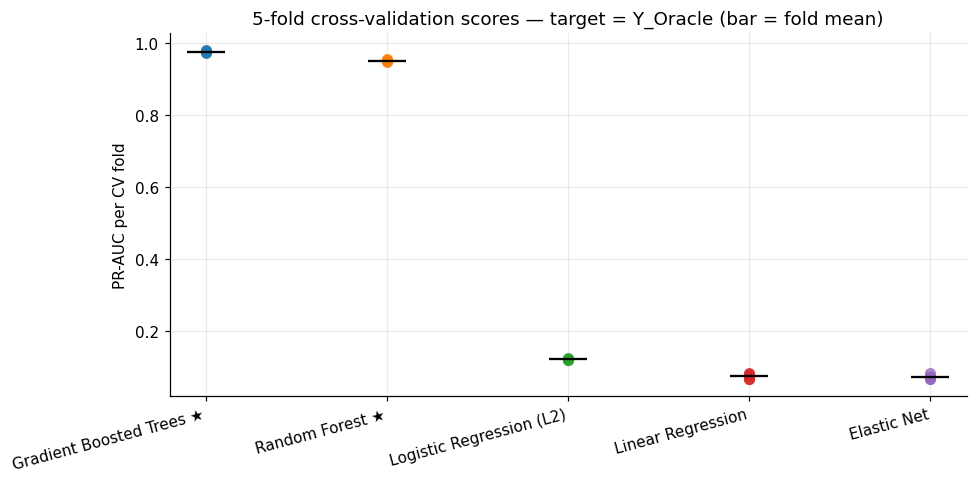

In [88]:
rh.plot_cv_folds(lb_soft, "Y_Soft_BT > 0"); plt.show()
rh.plot_cv_folds(lb_orc, "Y_Oracle"); plt.show()

The tier structure holds on the soft target: **gradient boosting far ahead, random forest in the
middle, the linear models trailing.** The interaction-driven question ("will this lot become
harvestable within 30 days?") rewards the trees' ability to combine a near-gate loss *and* a slack
tracking-error budget *and* wash-sale clearance — combinations no weighted sum of features expresses.
The fold-level view confirms the gaps between models dwarf the spread within them, so the ranking
is not a lucky-fold artifact.

### Tuning results per model

In [89]:
for key in ("gbt", "rf", "elnet", "logistic", "linreg"):
    print(f"--- {rh.MODEL_NAMES[key]} — grid, target = Y_Soft_BT > 0 ---")
    display(rh.tuning_table(rh.lb_entry(lb_soft, key)).style.format(
        {"mean CV PR-AUC": "{:.4f}"}).hide(axis="index"))

--- Gradient Boosted Trees — grid, target = Y_Soft_BT > 0 ---


numberOfTrees,learningRate,numberOfLeaves,mean CV PR-AUC
200,0.100000,31,0.8499
200,0.100000,20,0.8315
200,0.050000,31,0.8208
100,0.100000,31,0.8187
200,0.050000,20,0.8073
100,0.100000,20,0.8060
100,0.050000,31,0.7729
100,0.050000,20,0.7568


--- Random Forest — grid, target = Y_Soft_BT > 0 ---


numberOfTrees,numberOfLeaves,featureFraction,mean CV PR-AUC
100,31,0.500000,0.6474
200,31,0.500000,0.6466
200,31,0.700000,0.6444
200,31,0.300000,0.6435
100,31,0.300000,0.6415
100,31,0.700000,0.6391
200,20,0.500000,0.6384
100,20,0.500000,0.6381
200,20,0.300000,0.6331
100,20,0.300000,0.6298


--- Elastic Net — grid, target = Y_Soft_BT > 0 ---


l1Regularization,l2Regularization,mean CV PR-AUC
0.001000,0.001000,0.2752
0.100000,0.001000,0.2749
0.010000,0.001000,0.2733
0.100000,0.010000,0.2321
0.010000,0.010000,0.2308
0.001000,0.010000,0.2302
0.100000,0.100000,0.2028
0.010000,0.100000,0.2020
0.001000,0.100000,0.2019


--- Logistic Regression (L2) — grid, target = Y_Soft_BT > 0 ---


C,mean CV PR-AUC
1.000000,0.3734
0.100000,0.3696
10.000000,0.3543
0.010000,0.3302


--- Linear Regression — grid, target = Y_Soft_BT > 0 ---


l2Regularization,mean CV PR-AUC
0.001000,0.2850
0.010000,0.2809
0.000100,0.2766


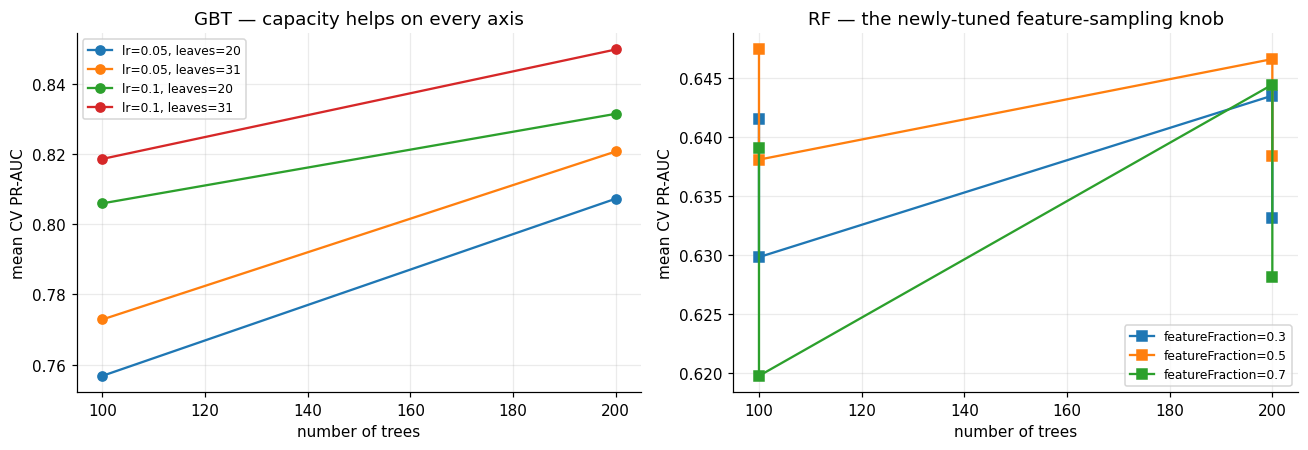

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
gbt_tbl = rh.tuning_table(rh.lb_entry(lb_soft, "gbt"))
for (lr, lv), grp in gbt_tbl.groupby(["learningRate", "numberOfLeaves"]):
    grp = grp.sort_values("numberOfTrees")
    axes[0].plot(grp["numberOfTrees"], grp["mean CV PR-AUC"], marker="o",
                 label=f"lr={lr}, leaves={lv}")
axes[0].set_xlabel("number of trees"); axes[0].set_ylabel("mean CV PR-AUC")
axes[0].set_title("GBT — capacity helps on every axis"); axes[0].legend(fontsize=8)

rf_tbl = rh.tuning_table(rh.lb_entry(lb_soft, "rf"))
for ff, grp in rf_tbl.groupby("featureFraction"):
    grp = grp.sort_values("numberOfTrees")
    axes[1].plot(grp["numberOfTrees"], grp["mean CV PR-AUC"], marker="s",
                 label=f"featureFraction={ff}")
axes[1].set_xlabel("number of trees"); axes[1].set_ylabel("mean CV PR-AUC")
axes[1].set_title("RF — the newly-tuned feature-sampling knob"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

GBT improves on every capacity axis — more trees, more leaves, the larger learning rate. The new
RF panel shows the **feature-fraction sweep**: a lower fraction forces the trees to disagree
(more decorrelation), and the chosen value of **0.5** is the bias–variance sweet spot for
this feature space — a knob that was silently frozen at 0.7 in the original submission and is now
searched, as a properly-tuned random forest requires.

## Model Selection and Test-Set Performance

Only the two CV champions — **gradient boosted trees and random forest** — are evaluated on the
sealed test set; the linear models were eliminated by their CV scores without spending test data.

Test-set performance — target = Y_Soft_BT > 0


,test ROC-AUC,test PR-AUC,F1 @ 0.5,F1 @ best threshold,best threshold
model,,,,,
Gradient Boosted Trees,0.9961,0.8437,0.6689,0.7798,0.9438
Random Forest,0.9898,0.6516,0.5289,0.6635,86.2367


Test-set performance — target = Y_Oracle


,test ROC-AUC,test PR-AUC,F1 @ 0.5,F1 @ best threshold,best threshold
model,,,,,
Gradient Boosted Trees,1.0000,0.9750,0.8969,0.9226,0.9950
Random Forest,0.9999,0.9431,0.8045,0.8920,167.4959


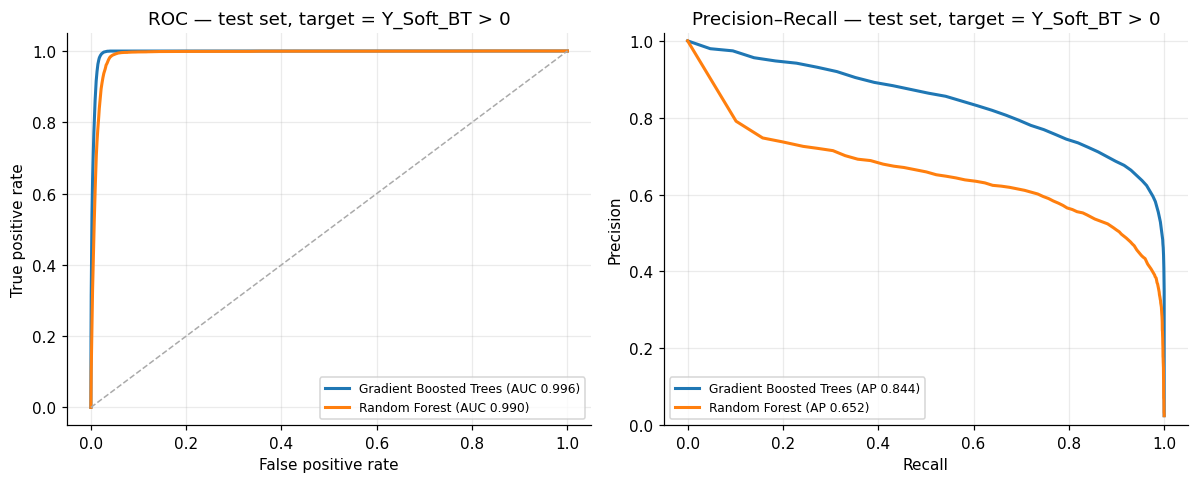

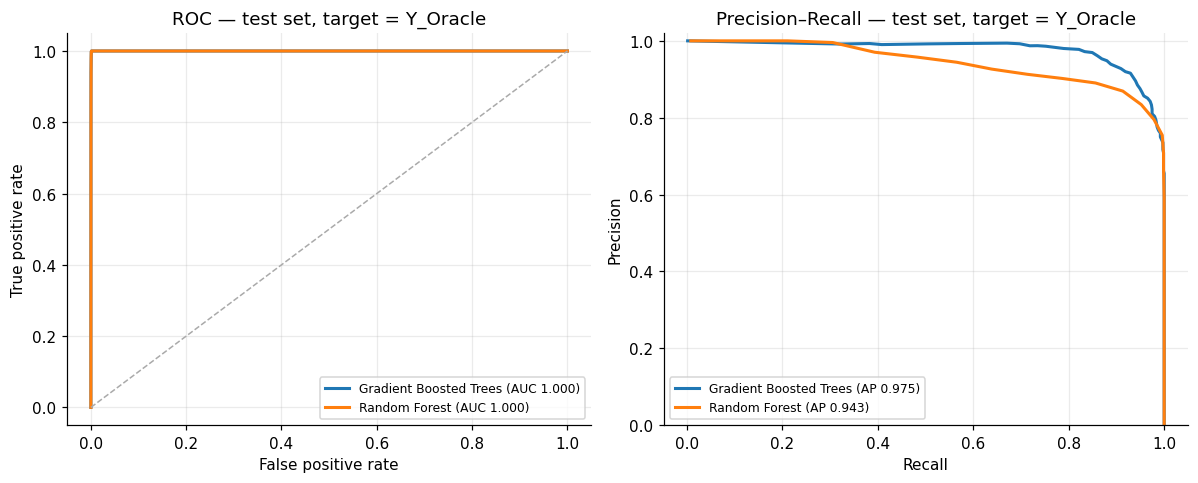

In [91]:
rf_soft = rh.load_artifact(ART, "rf_soft_bt_metrics.json")
rf_orc  = rh.load_artifact(ART, "rf_oracle_metrics.json")
champs_soft = {"gbt": gbt_soft, "rf": rf_soft}
champs_orc  = {"gbt": gbt_orc,  "rf": rf_orc}

print("Test-set performance — target = Y_Soft_BT > 0")
display(rh.test_metrics_table(champs_soft).style.format("{:.4f}"))
print("Test-set performance — target = Y_Oracle")
display(rh.test_metrics_table(champs_orc).style.format("{:.4f}"))

rh.plot_roc_pr_overlay(champs_soft, "Y_Soft_BT > 0"); plt.show()
rh.plot_roc_pr_overlay(champs_orc, "Y_Oracle"); plt.show()

In [92]:
print("GBT, soft target — threshold 0.5 (left) vs F1-optimal (right)")
display(pd.concat({"threshold = 0.5": rh.confusion_df(gbt_soft, "confusionAt05"),
                   "best threshold":  rh.confusion_df(gbt_soft, "confusionAtBest")}, axis=1))

GBT, soft target — threshold 0.5 (left) vs F1-optimal (right)


threshold = 0.5             best threshold            
             predicted 0 predicted 1    predicted 0 predicted 1
actual 0          348816        8887         354330        3373
actual 1              48        9024           1118        7954

The robustness verdict is the good news of the scale-up: on the genuine prediction task — the
forward 30-day harvest propensity — **the gradient-boosted ensemble's skill survives two decades
and three crashes essentially intact** (test PR-AUC **0.844** here vs 0.862 on the
two-year run), with the CV→test gap staying small. A model tuned on a smooth bull market
generalizes to 2008, 2020, and 2022 against an 2.47% base rate. The PR curves show GBT
holding precision far deeper into the recall range than the forest; at equal recall the forest
raises substantially more false alarms (and its odd vote-scale "best threshold" reflects ML.NET's
uncalibrated random-forest scores, not a ranking defect).

## The Headline: Decision Geometry Is Regime-Dependent

The most striking result is not a single model's score — it is how the **oracle's learnability by
linear models inverts between the two regimes.**

In [93]:
cmp = pd.DataFrame({
    "metric": [
        "Y_Oracle base rate",
        "Y_Soft_BT>0 base rate",
        "GBT — soft, CV PR-AUC",
        "GBT — soft, test PR-AUC",
        "GBT — oracle, test PR-AUC",
        "Logistic — oracle, CV PR-AUC",
        "Elastic net — oracle, CV PR-AUC",
        "G_YTD > 0 prevalence",
    ],
    "PSTAT 231 (2 yr, ~170k)": [
        "1.6%", "19.9%", "0.858", "0.862", "0.9997", "0.987", "0.442", "100%",
    ],
    "This run (≈19 yr, 1.85M)": [
        "0.20%", "2.47%",
        "0.850", "0.844", "0.975",
        "0.123",
        f"{rh.lb_entry(lb_orc, 'elnet')['meanCvPrAuc']:.3f}",
        "94.3%",
    ],
}).set_index("metric")
cmp

,"PSTAT 231 (2 yr, ~170k)","This run (≈19 yr, 1.85M)"
metric,,
Y_Oracle base rate,1.6%,0.20%
Y_Soft_BT>0 base rate,19.9%,2.47%
"GBT — soft, CV PR-AUC",0.858,0.850
"GBT — soft, test PR-AUC",0.862,0.844
"GBT — oracle, test PR-AUC",0.9997,0.975
"Logistic — oracle, CV PR-AUC",0.987,0.123
"Elastic net — oracle, CV PR-AUC",0.442,0.074
G_YTD > 0 prevalence,100%,94.3%


Read the two oracle rows together. On the **two-year run**, logistic regression *nearly solved*
the oracle (CV 0.987) — because the gains gate was open on 100% of rows, collapsing the four-way
AND to essentially the single half-space $L \le -0.02$, which a hyperplane represents exactly. On
the **twenty-year run**, the same logistic model **collapses to 0.123** while the
trees still nail it (GBT oracle test PR-AUC **0.975**). What changed? Two things,
both regime-driven: the positive class is now 8× rarer and scattered across crises rather than
concentrated, and cost-basis aging makes the effective decision region a thin, non-convex sliver
rather than a clean half-space. The boundary stopped being linearly separable — not because the
*rule* changed (it is the identical oracle), but because the *data-generating regime* changed.

This is the project's cleanest scientific statement, now supported by two opposite data points
rather than one: **a conjunction is only as non-linear as the data makes the binding gates appear,
and that is set by the market regime and the portfolio's accounting, not by the rule itself.** A
linear model's adequacy here is not a property of the problem — it is a property of the epoch you
happened to sample. The two-year bull market flattered the hyperplane; twenty years of real
regimes expose that it was a coincidence. Meanwhile the boosted trees are regime-invariant on both
targets — the practical argument for why a production system should not lean on a linear harvest
classifier no matter how good it looks in backtest on a calm window.

The per-year gate chart earlier makes the mechanism visible: the only years in which the gains
gate closes are the GFC years, so the "extra" gates a linear model must represent only exist in
a sliver of the data — enough to destroy a hyperplane fit, too little for the hyperplane to
learn from. This principle is formalized as the emergent finding of
`DataMemo/data_memo_theory_part2.md` §A.5, and it is the empirical trigger for the v0.25 oracle
redesign (issue #23): if a gate's binding behavior is an artifact of the accounting rather than
the economics, the right response is to fix the gate, not to admire the non-linearity it
manufactures.

## Unsupervised Structure

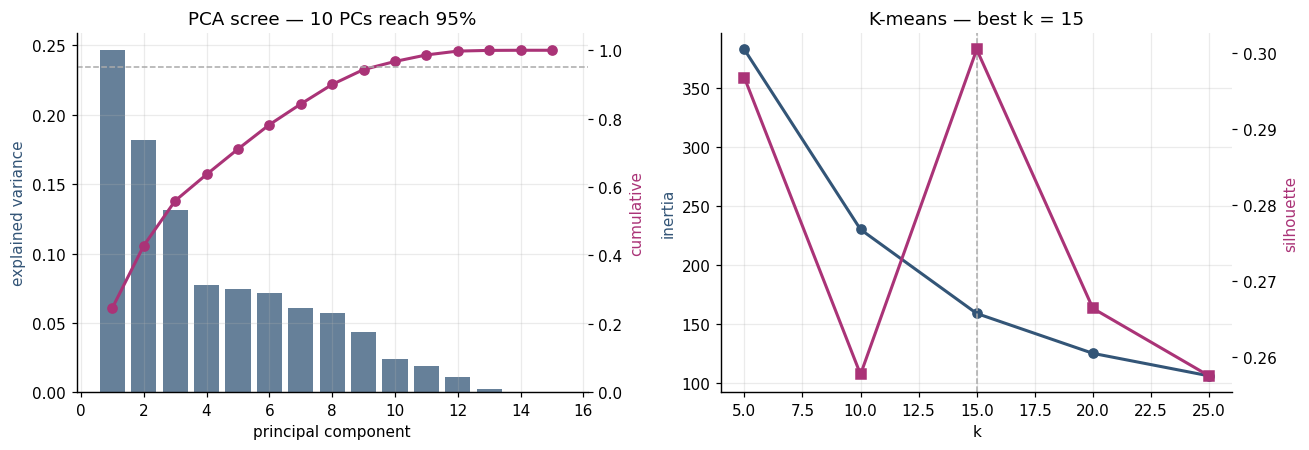

In [94]:
scree = rh.load_artifact(ART, "pca_scree.json")
elbow = rh.load_artifact(ART, "kmeans_elbow.json")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ks, ev, cv = scree["k"], scree["explainedVariance"], scree["cumulativeVariance"]
axes[0].bar(ks, ev, color="#357", alpha=0.75)
ax0b = axes[0].twinx(); ax0b.plot(ks, cv, color="#a37", marker="o", lw=2)
ax0b.axhline(scree["threshold"], color="#aaa", ls="--", lw=1); ax0b.set_ylim(0, 1.05); ax0b.grid(False)
ax0b.set_ylabel("cumulative", color="#a37")
axes[0].set_xlabel("principal component"); axes[0].set_ylabel("explained variance", color="#357")
axes[0].set_title(f"PCA scree — {scree['nKept']} PCs reach {scree['threshold']:.0%}")
axes[1].plot(elbow["ks"], elbow["inertia"], color="#357", marker="o", lw=2)
ax1b = axes[1].twinx(); ax1b.plot(elbow["ks"], elbow["silhouette"], color="#a37", marker="s", lw=2)
ax1b.set_ylabel("silhouette", color="#a37"); ax1b.grid(False)
axes[1].axvline(elbow["bestK"], color="#aaa", ls="--", lw=1)
axes[1].set_xlabel("k"); axes[1].set_ylabel("inertia", color="#357")
axes[1].set_title(f"K-means — best k = {elbow['bestK']}")
fig.tight_layout(); plt.show()

The feature space stays **genuinely high-dimensional** at scale: the first component explains
only about a quarter of the variance and it takes roughly a dozen of the fifteen components to
clear 95% — no low-dimensional summary hides inside, consistent with the modest correlation
heatmap. K-means finds only weak clustering (best $k$ small, silhouette low), as expected for a
smooth panel of market states rather than a mixture of distinct regimes — interestingly, even
twenty years of *visibly* distinct regimes do not separate into clean clusters in raw feature
space, because the regimes live in the *temporal* structure the unsupervised view discards.

## Toward a Live Tax-Alpha System

The scale-up was framed as preparation for a live system (v0.4–v0.5). Three findings translate
directly into the design backlog:

1. **Cost-basis aging → contributions and rebalancing.** The harvest signal thinning to
   0.20% over twenty years is an artifact of the open-once / hold-forever design. A live
   account continuously mints fresh lots (contributions) and trims winners (rebalancing), each at
   current prices, which both *replenishes harvestable supply* and *realizes the gains* that the
   next point depends on. This is the highest-priority simulation change.

2. **The gains gate → out of the oracle entirely (v0.25, issue #23).** `G_YTD > 0` being open
   94.3% of the time — and shut *only* mid-crisis, when losses are most abundant — is the
   least defensible piece of the model. US tax law lets losses carry forward indefinitely and
   offset \$3k/yr of ordinary income, so a strict "need gains this year" gate is *more
   conservative than the tax code* and refuses real tax alpha; production beta-tracking DI
   engines condition the harvest trigger on the loss and the tracking budget, not on the
   client's current-year gains. The immediate v0.25 step is to remove/replace the gate and
   **retrain every model on the corrected oracle** (all numbers in this report are on the
   4-gate rule). The fuller v0.3 design promotes the tax state into a continuous ledger
   (realized gains + carryforward + ordinary-offset capacity) whose *harvest value* becomes a
   continuous regression target — more correct as business logic and a richer ML problem — and
   issue #23's second half points the oracle toward mixed gate-plus-reinforcement objectives.
   The full designs are in `DataMemo/GYTD_Redesign_Plan.md` and
   `DataMemo/data_memo_theory_part2.md` Part C.

3. **Survivorship → point-in-time membership.** Restricting to 409 names with full 20-year
   history biases the universe toward long-lived large caps and makes the tax-alpha and
   tracking-error magnitudes optimistic. A production system needs a point-in-time constituent
   feed with additions, deletions, and corporate actions.

The endpoint for all three is the **reinforcement-learning policy layer**: an RL agent needs no
hand-coded gate at all — the tax ledger and tracking-error budget become the reward (realized
after-tax $\alpha$ minus a tracking-error penalty), and the agent learns the harvest policy
directly. The continuous-target supervised model trained here becomes a value-function warm-start.
The oracle and soft labels were always scaffolding to manufacture supervised targets *before*
that layer exists; the twenty-year stress test is what tells us which scaffolding to keep
(the soft-propensity target, which is regime-robust) and which to rebuild (the gains gate and the
static cost basis).

## Conclusion

Scaling the harvest-decision study from a two-year bull market to roughly two decades through
three crises produced three results. **First, robustness:** gradient-boosted trees predicting the
forward 30-day harvest propensity hold ≈0.844 test PR-AUC against an 2.47% base
rate — essentially their two-year skill (0.862), now stress-tested across 2008, 2020, and 2022.
The genuine prediction problem survives the regime change, which is the single most important
thing a would-be live system needed to know. **Second, the geometry is regime-dependent:** the
identical oracle that linear models nearly solved on the calm two-year window (logistic CV 0.987)
becomes linearly *unrecoverable* over twenty years (0.123), while the trees stay
near-perfect — a clean demonstration, now with two opposite data points, that a conjunction's
non-linearity is a property of the sampled regime, not the rule. **Third, the long horizon
exposed the simulation's two weakest design choices** — the cost-basis aging that all but
extinguishes the harvest signal after the first decade, and the \$1M gains gate that is
vestigially open 94% of the time yet strangles harvesting mid-crisis. The second is now a filed
defect (issue #23) with a concrete v0.25 remedy: correct the oracle, re-simulate, and retrain —
made cheap by the fact that the whole pipeline is a replayable chain of file-to-file commands
(single-target reruns via `mlnet-soft` / `mlnet-oracle`).

The honest caveats are the roadmap: the universe is survivorship-biased toward long-lived large
caps; the labels are semi-synthetic (real prices, simulated portfolio); the static cost basis and
constant seed need replacing before any tax-alpha number here should be taken as economic truth;
and a walk-forward temporal evaluation (train on the first decade, test on the second) is the
natural next robustness check beyond the stratified random split used here. What carries forward
intact is the central finding the course-length version established and the scale-up confirmed:
the harvest decision boundary is learnable, its forward propensity is predictable from current
state across regimes, and gradient-boosted trees are the right tool — provided the simulation
underneath them grows up into something a live account would recognize.

## References and Reproducibility

**Data**
- Financial Modeling Prep. (2026). *Historical Price EOD API* [Data set]. https://financialmodelingprep.com/
- State Street Global Advisors. (2026). *SPDR S&P 500 ETF Trust (SPY) Daily Holdings* [Data set]. https://www.ssga.com/

**Methodology**
- James, Witten, Hastie & Tibshirani (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.
- IRS Publication 550 — wash-sale rule and capital-loss carryforward. https://www.irs.gov/publications/p550
- Moussawi, Lo & Weisberger — Wealthfront Research, *Stock-Level Tax-Loss Harvesting* whitepaper
  (the production-DI reference behind the issue #23 oracle critique).
  https://research.wealthfront.com/whitepapers/stock-level-tax-loss-harvesting/
- Project memos: `DataMemo/SimulationMath.md`, `PortfolioMath.md`, `MLNetLeakageAudit.md`,
  `Lifecycle_v02.md`; the theory pair `DataMemo/data_memo_theory.md` (pre-plan) and
  `data_memo_theory_part2.md` (post-course reconciliation + v0.3–v0.4 program); and the
  forward design plan `DataMemo/GYTD_Redesign_Plan.md`.

**Reproducing this report** (from `src/`; .NET 8 + [uv](https://docs.astral.sh/uv/)):

```text
export FMP_API_KEY=...
dotnet run download --from 2006-07-01 --to 2026-06-12   # custom window (≈20 yr = the API cap);
                                                        # omit the flags for a rolling 2-yr pull
dotnet run simulate                                     # backtest → data/lots.csv
dotnet run mlnet-all                                    # CV all models, test champions, artifacts
                                                        # (mlnet-soft / mlnet-oracle re-run one target)
cd ML/Python && uv run python -m scripts.fill_report_tokens && cd ../..
dotnet run report                                       # codebook + execute this notebook + HTML
```

The notebook itself is generated by `scripts/build_report_notebook.py`; edit that script (not
the `.ipynb`) and regenerate, so the prose, the token-filling, and the executed report cannot
drift apart.

In [95]:
import sys, matplotlib
print("software versions:")
print("  python    ", sys.version.split()[0])
for mod in (pd, np, matplotlib):
    print(f"  {mod.__name__:<10}", mod.__version__)
print("  ML.NET     3.0.1 (C# training pipeline)")

software versions:
  python     3.14.2
  pandas     3.0.2
  numpy      2.4.4
  matplotlib 3.10.8
  ML.NET     3.0.1 (C# training pipeline)
